# The Illusion of Understanding: Do LLMs Really Know What They're Saying? 🤔

We've seen LLMs perform incredible tasks: they can reason with Chain-of-Thought, adopt expert personas, and even power autonomous agents.

### The Core Question
Their capabilities seem like intelligence. But the most important philosophical question we must ask is:

**"Do they actually *understand* the words they are processing?"**

### Today's Goal
This notebook explores that very question. We will dive into the fundamental concepts of **syntax** and **semantics** to explore the debate between true comprehension and sophisticated mimicry.


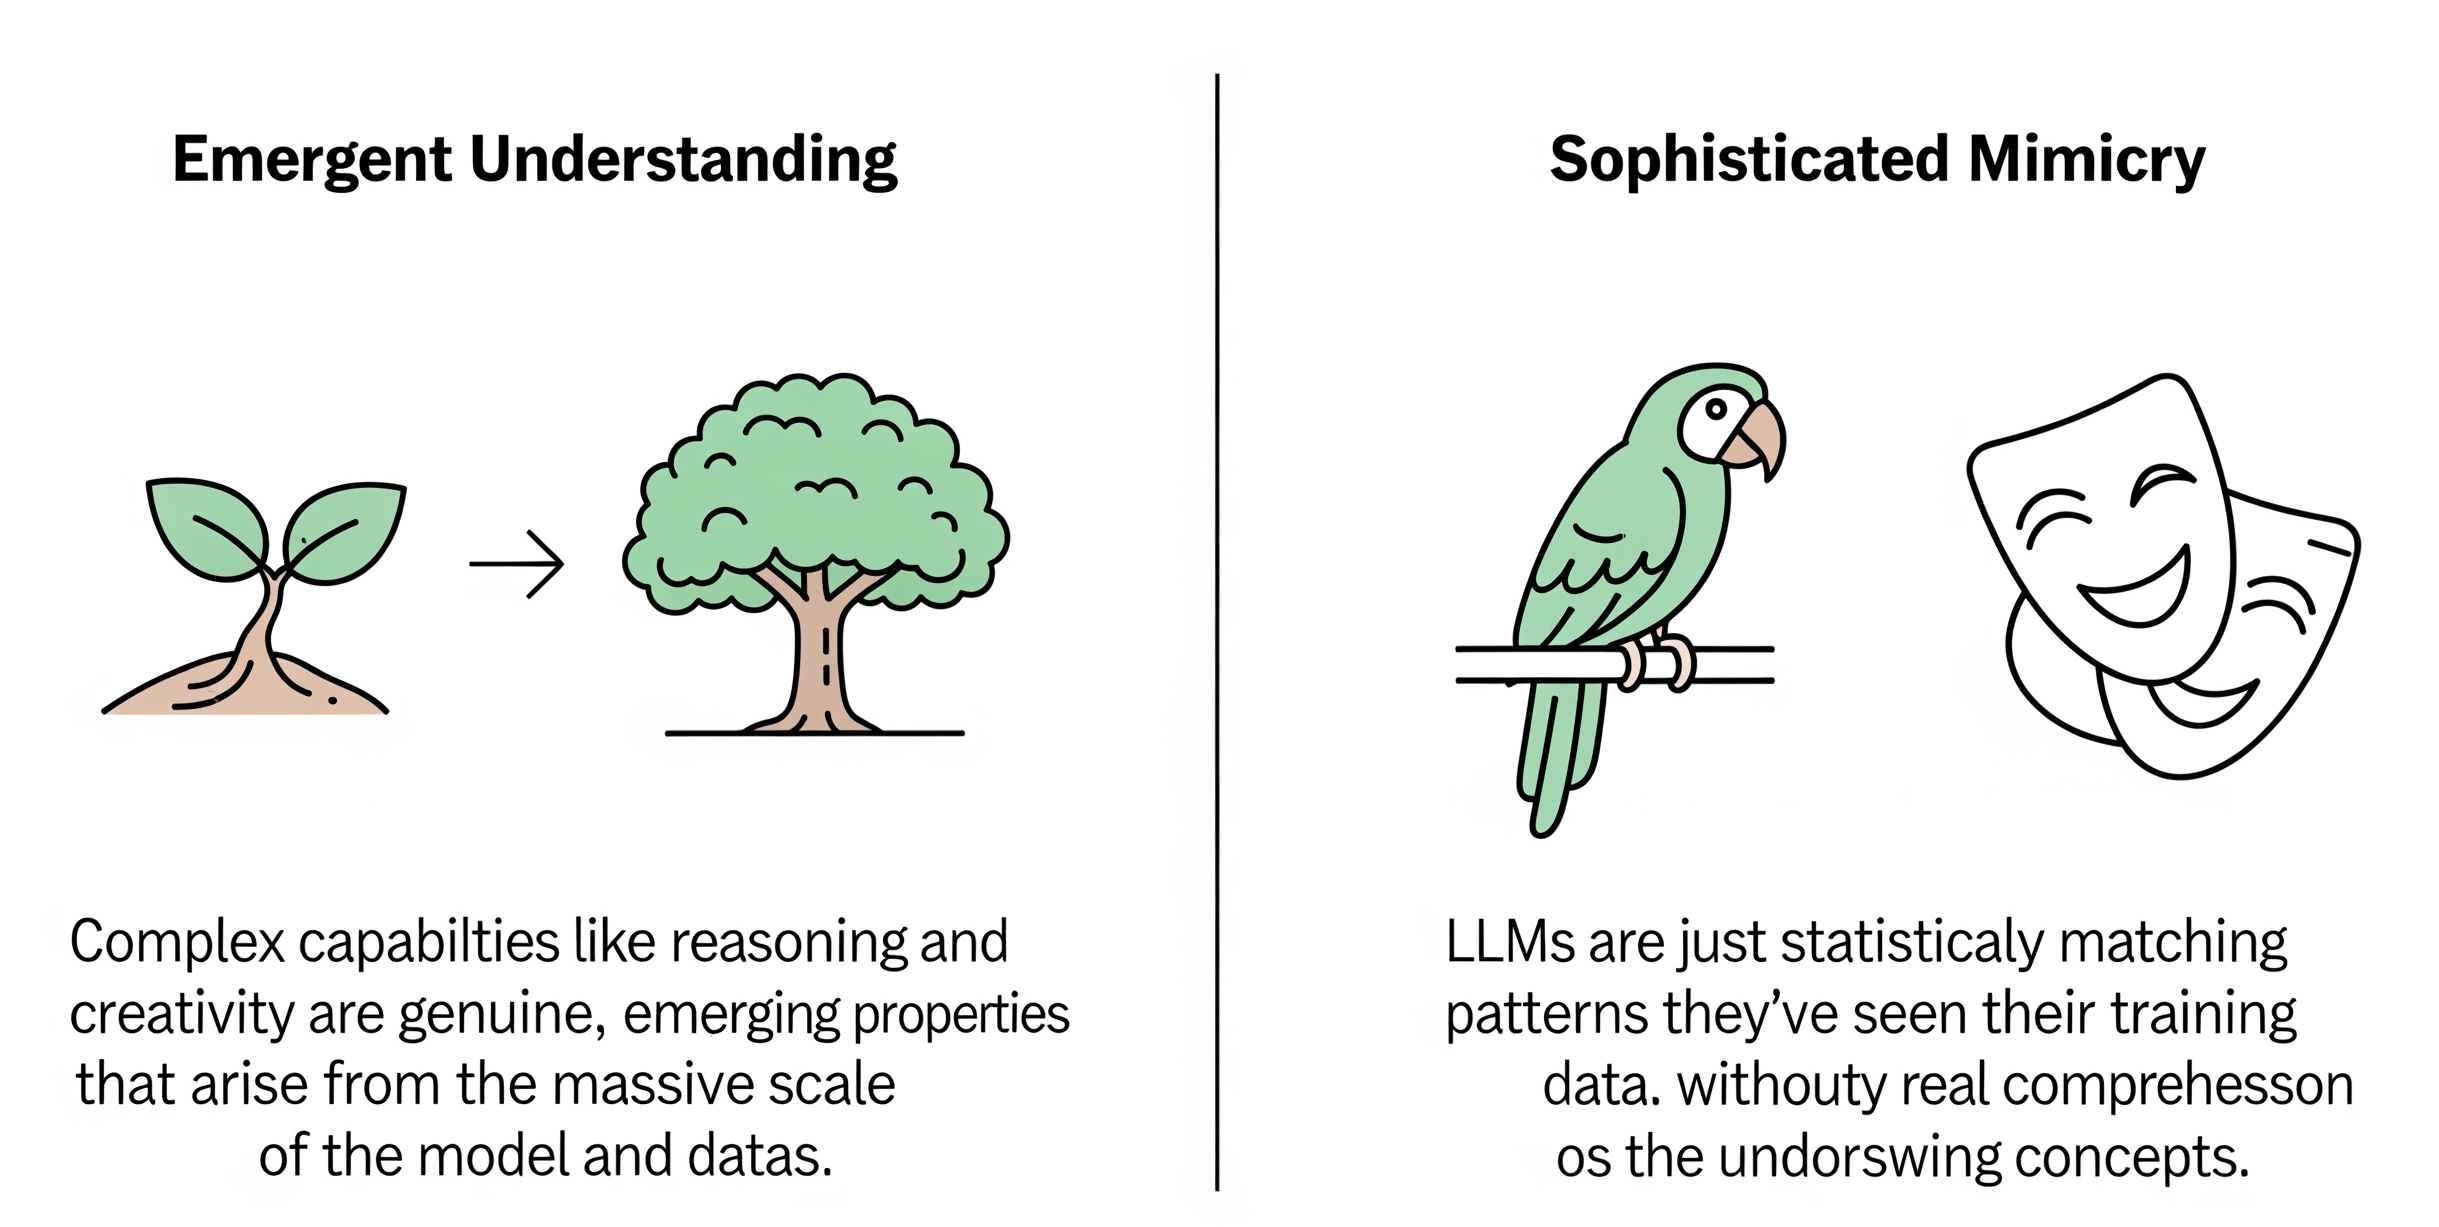

## What are Syntax and Semantics?

To tackle our question, we first need to define our terms. In linguistics, the distinction is clear:

###  syntactic (Syntax) 📜
This refers to the **rules of grammar** and structure in a language. It's about how words are correctly arranged to form a valid sentence. A syntax checker in a word processor knows if your sentence is grammatically correct, but it has no idea what it means.

* **Correct Syntax:** "The cat sat on the mat."
* **Incorrect Syntax:** "Sat mat the on cat."

### Semantic (Semantics) 💡
This refers to the **meaning behind the words** and sentences. It's about the concepts, ideas, and real-world knowledge that language represents. Semantics is what allows us to understand that "The cat sat on the mat" describes a feline resting on a floor covering.

A sentence can be syntactically perfect but semantically nonsensical, like Noam Chomsky's famous example: *"Colorless green ideas sleep furiously."*

## Demonstration 1: An LLM's Mastery of Syntax

LLMs are phenomenal at syntax. They have learned the grammatical patterns from trillions of words. We can easily demonstrate this by asking a model to judge grammatical correctness, even when the sentence has no real-world meaning.

In [1]:
# Install required libraries quietly
#!pip install transformers torch -q

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load a small, pre-trained model
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Craft a prompt to test syntax
prompt = """
Which of the following two sentences is grammatically correct?

1. Colorless green ideas sleep furiously.
2. Sleep ideas furiously green colorless.

The grammatically correct sentence is number
"""

# Tokenize and generate
input_ids = tokenizer.encode(prompt, return_tensors='pt')
output = model.generate(input_ids, max_new_tokens=2)
response = tokenizer.decode(output[0], skip_special_tokens=True)

print(response)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Which of the following two sentences is grammatically correct?

1. Colorless green ideas sleep furiously.
2. Sleep ideas furiously green colorless.

The grammatically correct sentence is number
3.


As you can see, the model correctly identifies sentence #1 as the grammatical one, even though it's meaningless. This is a pure demonstration of understanding **syntactic rules**.

---

## Demonstration 2: Testing for Semantics

Testing for meaning is harder. A good test involves checking if the model understands the *relationships between concepts*. We can do this with a classic "odd one out" task.

In [2]:
# A few-shot prompt to teach the model the semantic task
prompt = """
From the following list of words, which is the odd one out? Explain why.

List: [Dog, Cat, Table]
Odd one out: Table
Reason: A table is an inanimate piece of furniture, while a dog and a cat are living animals.

###
List: [Apple, Banana, Car]
Odd one out:
"""

# Tokenize and generate
input_ids = tokenizer.encode(prompt, return_tensors='pt')
output = model.generate(input_ids, max_length=100, num_beams=5, no_repeat_ngram_size=2)
response = tokenizer.decode(output[0], skip_special_tokens=True)

print(response)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



From the following list of words, which is the odd one out? Explain why.

List: [Dog, Cat, Table]
Odd one out: Table
Reason: A table is an inanimate piece of furniture, while a dog and a cat are living animals.

###
List: [Apple, Banana, Car]
Odd one out:
Table: The Apple is a table, but it is not an object of any kind. It is just


The model's answer in the previous cell might be correct, partially correct, or completely nonsensical. This variability is incredibly revealing and gets to the heart of our question. The model isn't using human-like logic, but rather a process based on **statistical relationships**.

Here’s how it *attempts* to solve the problem:

### A "Map" of Words
During its training on vast amounts of text, the model builds a high-dimensional "map" of language, known as a **vector space**. On this map, words are represented as points.
* Words that frequently appear in similar contexts (like "apple" and "banana," which are both fruits and foods) are placed **close together**.
* Words that appear in very different contexts (like "apple" and "car") are placed **far apart**.



When we ask the model to find the "odd one out," we are essentially asking it to perform a distance calculation on this map. It tries to identify which word-point is geometrically furthest from the cluster of the other points.

### Why It Succeeds or Fails
* **If the model answers correctly:** It means its statistical map for these specific words accurately reflects the conceptual relationships we understand. The "Car" vector was indeed the furthest from the "Apple" and "Banana" vectors.
* **If the model answers incorrectly or nonsensically (as is common with smaller models):** It reveals the limitations of this statistical approach. The model's internal map is flawed for this context, or it defaults to its primary function: predicting the next most probable word to complete the sentence structure (syntax), even if the underlying semantic calculation failed.

This is the core of the debate. The LLM uses its mastery of statistical patterns to **simulate** a task that requires genuine meaning (semantics). The quality of the simulation depends entirely on how well its internal map reflects the real world.

## The Philosophical Debate: Mimicry vs. Understanding

This leads us to the two main arguments in this debate.

### Argument 1: It's All Sophisticated Mimicry (Searle's Chinese Room)
The philosopher John Searle proposed a thought experiment called the **Chinese Room**.



Imagine a person who doesn't speak Chinese locked in a room. They receive Chinese characters (inputs), follow a complex rulebook (the program/model), and send out the correct Chinese characters (the output). To an outside observer, this person seems fluent in Chinese. But in reality, they don't understand a single word. They are just manipulating symbols based on rules.

**The nonsensical or incorrect output we might have seen in our demonstration is a powerful argument for this view.** When the model's statistical patterns aren't strong enough to form a coherent answer, it defaults to producing text that *looks* right (syntax) but lacks any real meaning (semantics)—just like the person in the Chinese Room following rules without comprehension.

### Argument 2: It's an Emergent Form of Understanding
The counter-argument is that at a certain scale, the distinction begins to blur.
* **Is our brain any different?** Our own consciousness and understanding arise from trillions of simple neural connections firing in complex patterns. Are we not, in a way, also just a very sophisticated pattern-matching machine?
* **Emergence:** When a system becomes complex enough, it can develop properties that its individual parts do not have. Perhaps "understanding" is an **emergent property** of a model that has perfectly mapped the statistical structure of language.
* **The Systems Reply:** A response to the Chinese Room argument is that while the person in the room doesn't understand Chinese, the *entire system* (the person, the room, the rulebook) as a whole does. Similarly, the LLM as a complete system might possess a form of understanding.

## Conclusion: An Unresolved Question

Ultimately, there is no consensus. The line between a perfect simulation of understanding and genuine understanding is blurry and perhaps impossible to prove.

From a **practical perspective**, a tool that can reliably perform tasks is useful regardless of whether it "truly" understands.

From a **philosophical and ethical perspective**, however, this is one of the most critical questions of our time. It challenges our definitions of intelligence, consciousness, and what it means to be human. **As we've seen, a simple model might fail a semantic test that a larger one would pass, but the core question remains: is the larger model truly understanding, or is it just a better mimic with a more detailed rulebook?**

Where do you draw the line between a pattern and a thought?